# Exploratory Data Analysis

Notebook ini berisi proses exploratory data analysis (EDA) untuk memahami pola pergerakan harga emas, melakukan data cleaning, dan menyiapkan dataset sebelum digunakan pada tahap machine learning.

# 1. Import Library

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# 2. Load Dataset

In [90]:
df = pd.read_csv('profin_raw.csv')

In [91]:
df.head()

,timestamp,adj_close,close,high,low,open,volume
0,NaN,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
1,2003-01-02,346.1000061035156,346.1000061035156,346.1000061035156,346.1000061035156,346.1000061035156,3
2,2003-01-03,351.20001220703125,351.20001220703125,351.20001220703125,345.20001220703125,345.20001220703125,0
3,2003-01-06,351.70001220703125,351.70001220703125,351.70001220703125,351.1000061035156,351.70001220703125,2
4,2003-01-07,347.29998779296875,347.29998779296875,349.29998779296875,347.29998779296875,349.29998779296875,4


# 3. Data Cleaning

In [92]:
df_clean = df.copy()

In [93]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5862 entries, 0 to 5861
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  5861 non-null   object
 1   adj_close  5862 non-null   object
 2   close      5862 non-null   object
 3   high       5862 non-null   object
 4   low        5862 non-null   object
 5   open       5862 non-null   object
 6   volume     5862 non-null   object
dtypes: object(7)
memory usage: 320.7+ KB


### Menghapus Baris yang Tidak Valid

In [94]:
df_clean = df_clean.dropna(subset=['timestamp'])

### Mengubah Tipe Data Timestamp

In [95]:
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])

### Mengubah Nama Kolom Timestamp Menjadi Date

In [96]:
df_clean.rename(columns={'timestamp': 'date'}, inplace=True)

### Menjadikan Kolom Date Sebagai Index

In [97]:
df_clean.set_index('date', inplace=True)

### Menghapus Kolom yang Tidak Digunakan

In [98]:
df_clean.drop(columns=['adj_close'], inplace=True)

Kolom adj_close dihapus karena memiliki informasi yang serupa dengan close sehingga tidak digunakan pada analisis.

### Mengubah Kolom Menjadi Numerik

In [99]:
numeric_cols = ['close', 'high', 'low', 'open', 'volume']

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

### Mengecek Missing Values

In [100]:
df_clean.isnull().sum()

close     0
high      0
low       0
open      0
volume    0
dtype: int64

### Mengecek Duplicate Data

In [101]:
df_clean.duplicated().sum()

8

In [102]:
df_clean = df_clean.drop_duplicates()

# 4. Exploratory Data Analysis(EDA)

## 4.1. Bagaimana tren harga emas dari waktu ke waktu?

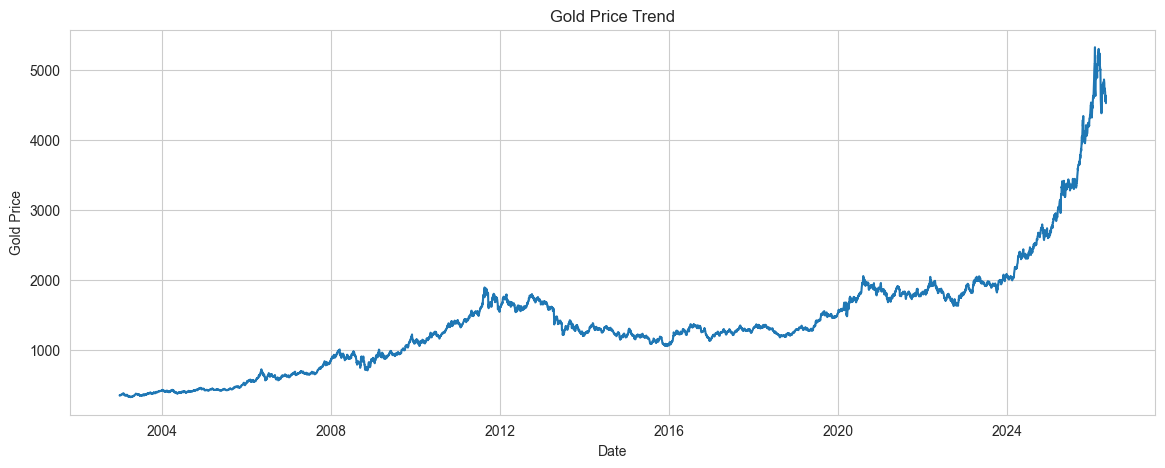

In [103]:
plt.figure(figsize=(14,5))

plt.plot(df_clean.index, df_clean['close'])

plt.title('Gold Price Trend')
plt.xlabel('Date')
plt.ylabel('Gold Price')

plt.show()

Harga emas menunjukkan tren yang cenderung meningkat dari tahun ke tahun meskipun terdapat beberapa fluktuasi pada periode tertentu. Pada periode terbaru terlihat kenaikan harga yang semakin signifikan dibandingkan tahun-tahun sebelumnya.

## 4.2. Bagaimana distribusi harga emas?

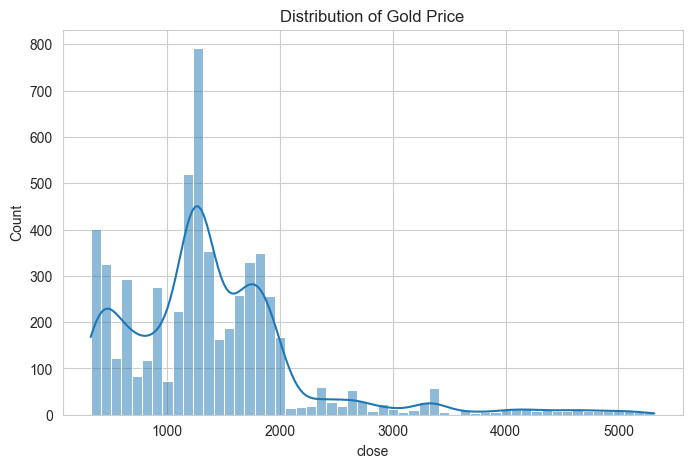

In [104]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean['close'], kde=True)

plt.title('Distribution of Gold Price')

plt.show()

Distribusi harga emas menunjukkan bahwa sebagian besar harga berada pada rentang tertentu, namun terdapat beberapa nilai harga yang jauh lebih tinggi dibandingkan data lainnya. Hal ini menunjukkan bahwa harga emas mengalami kenaikan signifikan pada beberapa periode tertentu.

## 4.3. Bagaimana perubahan volume transaksi dari waktu ke waktu?

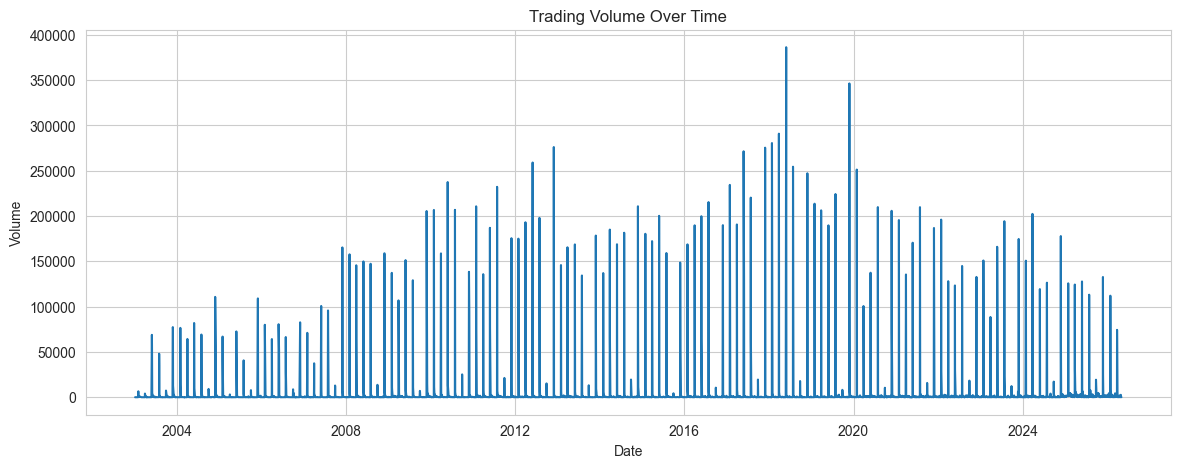

In [105]:
plt.figure(figsize=(14,5))

plt.plot(df_clean.index, df_clean['volume'])

plt.title('Trading Volume Over Time')

plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

Volume transaksi mengalami perubahan yang cukup signifikan pada beberapa periode. Terdapat beberapa lonjakan volume yang menunjukkan adanya peningkatan aktivitas transaksi emas pada waktu tertentu.

## 4.4. Apakah terdapat hubungan antar variabel numerik?

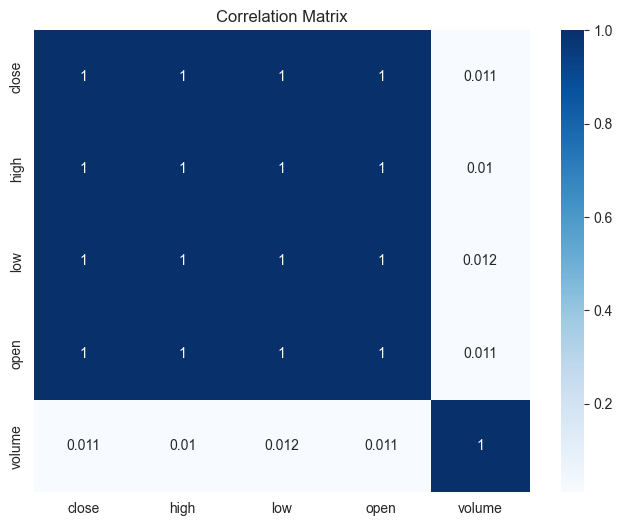

In [106]:
plt.figure(figsize=(8,6))

sns.heatmap(df_clean.corr(numeric_only=True),
            annot=True,
            cmap='Blues')

plt.title('Correlation Matrix')

plt.show()

Variabel open, high, low, dan close memiliki hubungan yang sangat kuat karena seluruhnya merepresentasikan pergerakan harga emas pada periode yang sama. Sementara itu, volume memiliki hubungan yang relatif rendah terhadap variabel harga.

# 5. Kesimpulan

In [107]:
df.head()

,timestamp,adj_close,close,high,low,open,volume
0,NaN,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
1,2003-01-02,346.1000061035156,346.1000061035156,346.1000061035156,346.1000061035156,346.1000061035156,3
2,2003-01-03,351.20001220703125,351.20001220703125,351.20001220703125,345.20001220703125,345.20001220703125,0
3,2003-01-06,351.70001220703125,351.70001220703125,351.70001220703125,351.1000061035156,351.70001220703125,2
4,2003-01-07,347.29998779296875,347.29998779296875,349.29998779296875,347.29998779296875,349.29998779296875,4


In [108]:
df_clean.head()

,close,high,low,open,volume
date,,,,,
2003-01-02,346.100006,346.100006,346.100006,346.100006,3
2003-01-03,351.200012,351.200012,345.200012,345.200012,0
2003-01-06,351.700012,351.700012,351.100006,351.700012,2
2003-01-07,347.299988,349.299988,347.299988,349.299988,4
2003-01-08,353.899994,353.899994,346.299988,346.799988,0


Berdasarkan exploratory data analysis yang telah dilakukan, harga emas menunjukkan tren yang cenderung meningkat dalam jangka panjang meskipun terdapat beberapa fluktuasi pada periode tertentu. Pada periode terbaru terlihat kenaikan harga yang semakin signifikan dibandingkan periode sebelumnya.

Distribusi harga menunjukkan adanya variasi nilai harga dengan beberapa harga tinggi pada periode terbaru. Selain itu, variabel open, high, low, dan close memiliki hubungan yang sangat kuat karena merepresentasikan pergerakan harga emas pada waktu yang sama. Sementara itu, volume transaksi memiliki hubungan yang relatif rendah terhadap variabel harga.

Proses data cleaning juga telah dilakukan dengan menghapus data yang tidak valid, mengubah tipe data, menjadikan kolom date sebagai index, serta menghapus kolom yang tidak digunakan. Dataset hasil cleaning kemudian disimpan dan siap digunakan untuk tahap selanjutnya.

# 6. Data Saving

In [109]:
df_clean.to_csv('profin_clean.csv')